In [11]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load features and target from parquet files
features_path = "../data/user_activity/featured/features.parquet"
target_path = "../data/user_activity/featured/target.parquet"

X = pd.read_parquet(features_path)
y_loaded = pd.read_parquet(target_path)

       posts_week2
0                2
1                0
2                1
3               39
4                0
...            ...
48620            0
48621            2
48622            1
48623            1
48624            0

[48625 rows x 1 columns]
0         2
1         0
2         1
3        39
4         0
         ..
48620     0
48621     2
48622     1
48623     1
48624     0
Name: posts_week2, Length: 48625, dtype: int64


## Bucketing strategy and plan

We'll convert the integer count target `posts_week2` into four ordered activity classes:
- 0 posts -> class 0 (Inactive)
- 1–3 posts -> class 1
- 4–10 posts -> class 2
- 11+ posts -> class 3 (Highly active)

After binning we'll: 
1. Inspect class distribution.
2. Split into train/test with stratification by class.
3. Train multiple multiclass classifiers (Logistic Regression, Random Forest, Gradient Boosting).
4. Evaluate with accuracy, macro F1, and the classification report + confusion matrix.

This makes the problem easier to interpret than a raw count regression while still distinguishing low vs high activity.

In [15]:
# Create multi-class target by binning counts into activity bands
# We expect y_loaded to be a DataFrame with column 'posts_week2' as shown in your example
if isinstance(y_loaded, pd.DataFrame):
    if 'posts_week2' in y_loaded.columns:
        y_counts = y_loaded['posts_week2'].astype(int)
    elif y_loaded.shape[1] == 1:
        y_counts = y_loaded.iloc[:, 0].astype(int)
    else:
        # fallback: try to pick a likely count column
        candidates = [c for c in y_loaded.columns if 'post' in c.lower() or 'count' in c.lower()]
        if candidates:
            y_counts = y_loaded[candidates[0]].astype(int)
        else:
            raise ValueError('Cannot find a suitable count column in target parquet. Expected posts_week2.')
else:
    # if a Series-like object was loaded
    y_counts = pd.Series(y_loaded).astype(int)

# Define bins and labels: note upper bound for last bin is infinity
bins = [-1, 0, 3, 10, float('inf')]
labels = [0, 1, 2, 3]  # 0=inactive, 1=low, 2=medium, 3=high
y_multi = pd.cut(y_counts, bins=bins, labels=labels).astype(int)

print('Class distribution (label:count):')
print(y_multi.value_counts().sort_index())

# Sanity check: show mapping for a few values
example_map = pd.DataFrame({'count': y_counts.sample(10, random_state=1), 'class': y_multi.sample(10, random_state=1)})
print('Sample mapping (count -> class):')
print(example_map.sort_index())

Class distribution (label:count):
posts_week2
0    21357
1    17884
2     6076
3     3308
Name: count, dtype: int64
Sample mapping (count -> class):
       count  class
906        0      0
1661       1      1
7314       0      0
26697      3      1
30667     10      2
33526     11      3
33581      5      2
37340      1      1
43186      2      1
47064      0      0


In [17]:
# Prepare features and split (stratify by class to preserve distribution)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_multi, test_size=0.2, random_state=42, stratify=y_multi)
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print('Train class distribution:')
print(y_train.value_counts(normalize=True))

# Scale numeric features for linear models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define multiclass models: LogisticRegression (multinomial), RandomForest, GradientBoosting
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

models = {
    'LogisticRegression': LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, class_weight='balanced', random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    print(f'\n===== Training {name} =====')
    # Use scaled features for logistic, raw/ scaled both work for tree models; we'll use scaled consistently
    Xtr = X_train_scaled if name == 'LogisticRegression' else X_train
    Xte = X_test_scaled if name == 'LogisticRegression' else X_test
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    print(f'Accuracy: {acc:.4f}, Macro F1: {f1_macro:.4f}')
    print('Classification report:')
    print(classification_report(y_test, y_pred, digits=4))
    cm = confusion_matrix(y_test, y_pred)
    print('Confusion matrix (rows=true, cols=pred):')
    print(cm)
    results[name] = dict(model=model, accuracy=acc, f1_macro=f1_macro, confusion=cm)


X_train: (38900, 20), X_test: (9725, 20)
Train class distribution:
posts_week2
0    0.439229
1    0.367789
2    0.124961
3    0.068021
Name: proportion, dtype: float64

===== Training LogisticRegression =====
Accuracy: 0.5382, Macro F1: 0.4901
Classification report:
              precision    recall  f1-score   support

           0     0.6697    0.6289    0.6486      4271
           1     0.5618    0.4825    0.5192      3577
           2     0.2382    0.3226    0.2740      1215
           3     0.4317    0.6495    0.5187       662

    accuracy                         0.5382      9725
   macro avg     0.4753    0.5209    0.4901      9725
weighted avg     0.5599    0.5382    0.5454      9725

Confusion matrix (rows=true, cols=pred):
[[2686  974  507  104]
 [1059 1726  616  176]
 [ 209  328  392  286]
 [  57   44  131  430]]

===== Training RandomForest =====
Accuracy: 0.5382, Macro F1: 0.4901
Classification report:
              precision    recall  f1-score   support

           0    


Best model by macro F1: GradientBoosting (F1=0.5115)


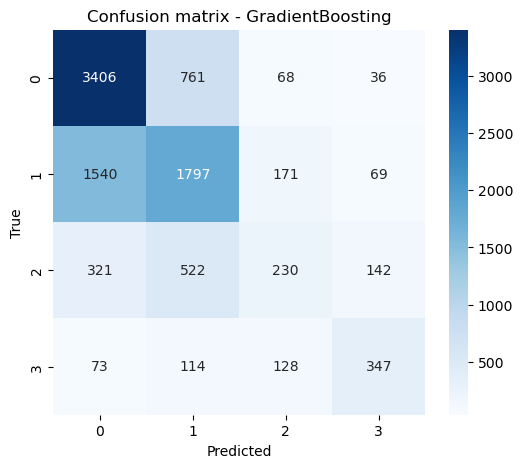

Saved best model and scaler to ../data/posting/featured/best_multiclass_model.pkl


In [19]:
# Optional: plot confusion matrix for the best model by macro F1
best_name = max(results.keys(), key=lambda k: results[k]['f1_macro'])
best = results[best_name]['model']
print(f"\nBest model by macro F1: {best_name} (F1={results[best_name]['f1_macro']:.4f})")

import seaborn as sns
plt.figure(figsize=(6,5))
cm = results[best_name]['confusion']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion matrix - {best_name}')
plt.show()

# Save the best model object to disk if desired (pickle)
import pickle
with open('../data/posting/featured/best_multiclass_model.pkl', 'wb') as f:
    pickle.dump({'name': best_name, 'model': best, 'scaler': scaler}, f)
print('Saved best model and scaler to ../data/posting/featured/best_multiclass_model.pkl')